# Customer segmentation with RFM + k-means (UK online retailer)

**Question.** Which groups of customers drive revenue, and who should marketing prioritise for retention versus win-back?

**Data.** UCI Online Retail: 541,909 invoice lines from a UK gift retailer, Dec 2010 – Dec 2011. See `data/README.md`.

**What changed from the first version.**
- Cancelled invoices and returns are now excluded (they produced customers with £0 spend).
- Frequency counts distinct invoices, not invoice *lines*.
- Skewed spend and frequency are log-transformed instead of dropping IQR "outliers". The old approach removed the highest-value customers.
- The number of clusters is chosen with silhouette scores.
- Fixes a bug where cluster labels were attached with `pd.concat(axis=1)` to a filtered DataFrame whose index had gaps,
  which misaligned labels and customers and made every segment look alike.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
sns.set_theme(style="whitegrid"); pd.set_option("display.precision", 1)
raw = pd.read_csv("data/Online Retail.csv", encoding="ISO-8859-1", parse_dates=["InvoiceDate"])
print(f"{len(raw):,} lines | missing CustomerID {raw.CustomerID.isna().mean():.1%}")

541,909 lines | missing CustomerID 24.9%


## 1. Clean: identified customers, completed sales only

In [2]:
df = raw.dropna(subset=["CustomerID"])
df = df[~df.InvoiceNo.astype(str).str.startswith("C") & (df.Quantity > 0) & (df.UnitPrice > 0)].copy()
df["revenue"] = df.Quantity * df.UnitPrice
print(f"{len(df):,} sale lines | {df.CustomerID.nunique():,} customers | {df.InvoiceNo.nunique():,} invoices | revenue £{df.revenue.sum():,.0f}")

397,884 sale lines | 4,338 customers | 18,532 invoices | revenue £8,911,408


## 2. RFM features per customer
Recency = days since the last purchase (snapshot = day after the last invoice), Frequency = distinct invoices, Monetary = total spend.

In [3]:
snapshot = df.InvoiceDate.max() + pd.Timedelta(days=1)
rfm = df.groupby("CustomerID").agg(recency=("InvoiceDate", lambda s: (snapshot - s.max()).days),
                                   frequency=("InvoiceNo", "nunique"), monetary=("revenue", "sum"))
display(rfm.describe(percentiles=[.25, .5, .75, .95]).T)
X = StandardScaler().fit_transform(np.column_stack([rfm.recency, np.log1p(rfm.frequency), np.log1p(rfm.monetary)]))

,count,mean,std,min,25%,50%,75%,95%,max
recency,4338.0,92.5,100.0,1.0,18.0,51.0,142.0,312.0,374.0
frequency,4338.0,4.3,7.7,1.0,1.0,2.0,5.0,13.0,209.0
monetary,4338.0,2054.3,8989.2,3.8,307.4,674.5,1661.7,5841.8,280206.0


## 3. How many segments? Silhouette score for k = 2…8

In [4]:
sil = {k: silhouette_score(X, KMeans(k, n_init=10, random_state=0).fit_predict(X), sample_size=3000, random_state=0) for k in range(2, 9)}
print({k: round(v, 3) for k, v in sil.items()})
# k = 2 always scores highest on RFM data but is too coarse to act on; take the best k from 3 upward
K = max((k for k in sil if k >= 3), key=sil.get); print("chosen k:", K)

{2: 0.411, 3: 0.411, 4: 0.383, 5: 0.343, 6: 0.33, 7: 0.297, 8: 0.3}
chosen k: 3


## 4. Segment profiles

In [5]:
km = KMeans(K, n_init=10, random_state=0).fit(X)
rfm["segment_id"] = km.labels_  # assigned by position on the same rows: no index alignment issues
prof = rfm.groupby("segment_id").agg(customers=("recency", "size"), median_recency_days=("recency", "median"),
                                      median_orders=("frequency", "median"), median_spend=("monetary", "median"), revenue=("monetary", "sum"))
prof["share_of_customers"] = prof.customers / prof.customers.sum() * 100
prof["share_of_revenue"] = prof.revenue / prof.revenue.sum() * 100

def name(r):
    if r.median_recency_days <= 30 and r.median_orders >= 5: return "Champions"
    if r.median_recency_days <= 60 and r.median_orders >= 2: return "Loyal / active"
    if r.median_recency_days > 150 and r.median_orders <= 1: return "Lost one-timers"
    if r.median_recency_days > 90: return "At risk"
    return "New / occasional"
prof["segment"] = prof.apply(name, axis=1)
prof = prof.sort_values("share_of_revenue", ascending=False)
display(prof[["segment", "customers", "share_of_customers", "share_of_revenue", "median_recency_days", "median_orders", "median_spend"]])

,segment,customers,share_of_customers,share_of_revenue,median_recency_days,median_orders,median_spend
segment_id,,,,,,,
2,Champions,1324,30.5,81.6,17.0,7.0,2575.2
0,Loyal / active,2032,46.8,14.0,45.0,2.0,508.8
1,Lost one-timers,982,22.6,4.4,252.5,1.0,292.7


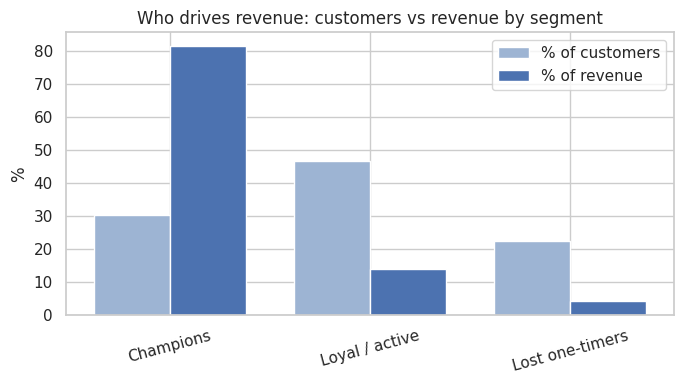

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(prof)); w = 0.38
ax.bar(x - w/2, prof.share_of_customers, w, label="% of customers", color="#9DB4D3")
ax.bar(x + w/2, prof.share_of_revenue, w, label="% of revenue", color="#4C72B0")
ax.set_xticks(x, prof.segment, rotation=15); ax.set_ylabel("%"); ax.legend(); ax.set_title("Who drives revenue: customers vs revenue by segment")
plt.tight_layout(); plt.savefig("images/segments_revenue.png", dpi=120); plt.show()